# Grammar Scoring Engine for Spoken English

Predicts a 0–5 grammar score (MOS Likert) from a 45–60 s audio clip. 769 labelled training clips, 216 test clips.
Leaderboard metrics: Pearson r and RMSE.

```
audio ─► noise filter ─► VAD ─┬─► ASR: Whisper medium + wav2vec2 ─► clean + raw transcripts
                              │                                        │
                              │                         DeBERTa (clean) ┤  DeBERTa (raw)
                              │                                        │
                              └─► WavLM audio embeddings ─► ridge ─────┤
                                                                       ▼
                                              non-negative blend ─► calibration ─► score 0–5
```

The engine has two halves: a model that **reads** what was said (fine-tuned DeBERTa on the transcript) and a model
that **listens** to how it was said (WavLM). Hand-built grammar features (LanguageTool, CoLA, spaCy) are kept for
interpretation. Evaluation uses speaker-grouped, nested cross-validation. The report is in Section 11; the full
experiment history, including what did not work, is in `development/EXPERIMENTS.md`.

**Running on Colab:** Runtime → Change runtime type → **T4 GPU**. Add your Kaggle token as a Colab secret
(key icon, left sidebar, notebook access on): either `KAGGLE_API_TOKEN` (new `KGAT_…` token) or
`KAGGLE_USERNAME` + `KAGGLE_KEY` (from `kaggle.json`). Then Run all. Slow steps are cached on Google Drive.

## 1. Setup

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
_env = os.path.dirname(os.path.dirname(sys.executable))                          # conda env: put its java/CLIs first
os.environ["PATH"] = f"{_env}/lib/jvm/bin:{_env}/bin:{os.environ['PATH']}"
if IN_COLAB:
    subprocess.run("pip install -q faster-whisper language-tool-python silero-vad lightgbm shap kaggle", shell=True)
    subprocess.run("apt-get -qq install -y openjdk-17-jre-headless > /dev/null", shell=True)   # LanguageTool needs Java 17+
    subprocess.run("python -m spacy download -q en_core_web_sm", shell=True)

In [2]:
import json, re, time, warnings
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
import torch
from scipy.stats import pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SR, SEED = 16_000, 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"                  # faster-whisper: cuda or cpu
TORCH_DEVICE = DEVICE if DEVICE == "cuda" else "mps" if torch.backends.mps.is_available() else "cpu"
WHISPER_SIZE = "medium"
COMPETITION = "shl-hiring-assessment-2026"

if IN_COLAB:
    from google.colab import drive, userdata
    drive.mount("/content/drive")
    CACHE = Path("/content/drive/MyDrive/shl_grammar/cache")
    DATA_ROOT = Path("/content/data")
else:
    CACHE = Path("cache")
    DATA_ROOT = Path(".")
CACHE.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(SEED)
print(f"device={DEVICE}/{TORCH_DEVICE}  whisper={WHISPER_SIZE}  cache={CACHE}")

device=cpu/mps  whisper=medium  cache=cache


## 2. Data

Train and test folders **reuse filenames** with different audio, so every clip is keyed as `train/…` or `test/…`.
`sample_submission.csv` does not match `test.csv`; the submission is built from `test.csv`.

In [3]:
if IN_COLAB and not any(DATA_ROOT.rglob("train.csv")):
    def secret(name):
        try:
            return userdata.get(name)
        except Exception:
            return None
    if secret("KAGGLE_API_TOKEN"):                       # new-style token (KGAT_...)
        os.environ["KAGGLE_API_TOKEN"] = secret("KAGGLE_API_TOKEN")
    else:                                                # classic kaggle.json username + key
        os.environ["KAGGLE_USERNAME"] = secret("KAGGLE_USERNAME")
        os.environ["KAGGLE_KEY"] = secret("KAGGLE_KEY")
    subprocess.run("pip install -q -U kaggle", shell=True)
    DATA_ROOT.mkdir(exist_ok=True)
    subprocess.run(f"kaggle competitions download -c {COMPETITION} -p {DATA_ROOT} -q", shell=True, check=True)
    subprocess.run(f"cd {DATA_ROOT} && unzip -q -o '*.zip' && rm -f *.zip", shell=True, check=True)
DATA = next(p.parent for p in DATA_ROOT.rglob("train.csv") if (p.parent / "train").is_dir())

train = pd.read_csv(DATA / "train.csv").assign(split="train")
test = pd.read_csv(DATA / "test.csv").assign(split="test", label=np.nan)
df = pd.concat([train, test], ignore_index=True)
df["key"] = df.split + "/" + df.filename
df["path"] = [str(DATA / k) for k in df.key]
df["duration"] = [librosa.get_duration(path=p) for p in tqdm(df.path, desc="durations")]
print(DATA, "| train", len(train), "| test", len(test))
print(df.groupby("split").duration.describe().round(1))

Dataset_Final | train 769 | test 216
       count  mean  std   min   25%   50%   75%   max
split                                                
test   216.0  48.8  8.2   6.5  45.1  45.1  60.0  61.0
train  769.0  55.8  7.9  20.1  54.2  60.1  60.1  61.0


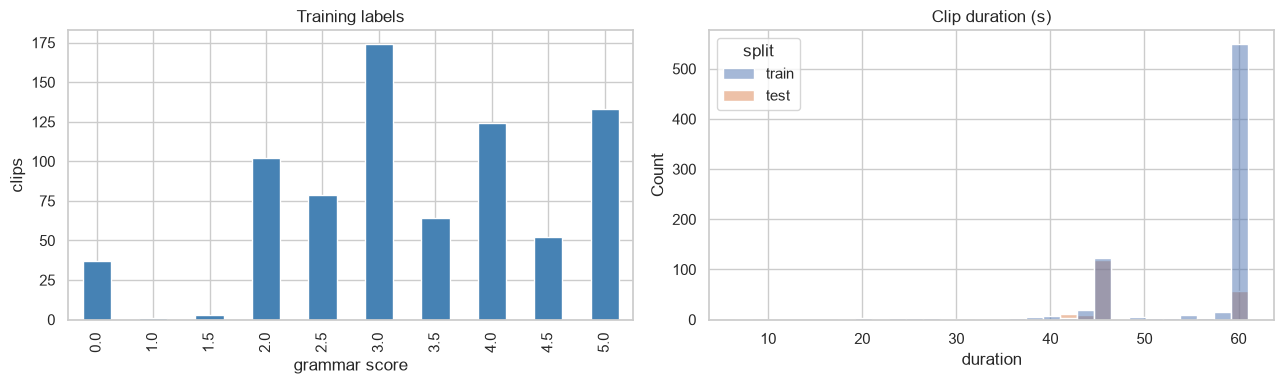

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
train.label.value_counts().sort_index().plot.bar(ax=ax[0], color="steelblue")
ax[0].set(title="Training labels", xlabel="grammar score", ylabel="clips")
sns.histplot(data=df, x="duration", hue="split", bins=30, ax=ax[1]); ax[1].set(title="Clip duration (s)")
plt.tight_layout(); plt.show()

* Labels sit on a 0.5 grid and lean high (≈17 % at 5.0); only 4 clips fall between 1.0 and 1.5.
* 37 clips are scored 0, which the rubric does not define (Section 3).
* Test clips are shorter than train clips (median 45 s vs 60 s), so **every feature is a rate**
  (per 100 words, per minute), never a raw count.

## 3. Noise-only clips

Frame energy statistics per clip: median level, dynamic range (p90 − p10) and spectral flatness.
Speech varies by ~40 dB; steady noise does not.

label == 0  False  True 
flagged                 
False         732      0
True            0     37
test clips flagged: 0


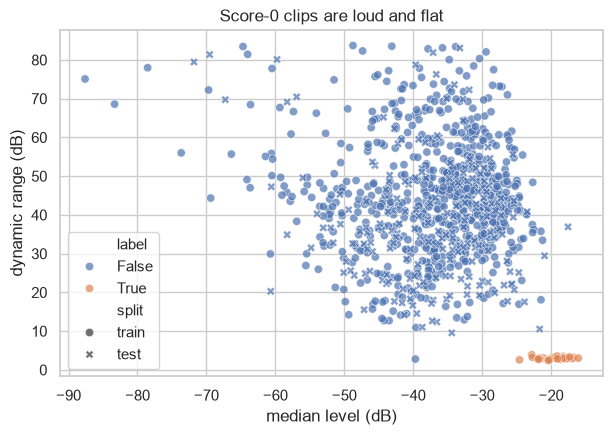

In [5]:
def audio_quality(path):
    y, _ = librosa.load(path, sr=SR)
    frames = librosa.util.frame(y, frame_length=400, hop_length=400)
    e = 10 * np.log10((frames ** 2).mean(axis=0) + 1e-10)
    flat = librosa.feature.spectral_flatness(y=y, n_fft=400, hop_length=400)[0]
    return dict(level_db=np.median(e), noise_floor_db=np.percentile(e, 10),
                dyn_range_db=np.percentile(e, 90) - np.percentile(e, 10), flatness=np.median(flat))

def cached_table(name, fn, keys, paths):
    # per-clip feature table, cached as parquet; computes only missing keys
    path = CACHE / f"{name}.parquet"
    old = pd.read_parquet(path) if path.exists() else pd.DataFrame()
    todo = [(k, p) for k, p in zip(keys, paths) if k not in old.index]
    if todo:
        new = pd.DataFrame([fn(p) for _, p in tqdm(todo, desc=name)], index=[k for k, _ in todo])
        old = pd.concat([old, new]); old.to_parquet(path)
    return old.loc[list(keys)]

quality = cached_table("quality", audio_quality, df.key, df.path)
df = df.join(quality, on="key")
df["noise_only"] = (df.dyn_range_db < 8) & (df.level_db > -28) & (df.flatness > 0.5)
tr = df[df.split == "train"]
print(pd.crosstab(tr.noise_only, tr.label == 0, rownames=["flagged"], colnames=["label == 0"]))
print("test clips flagged:", df[df.split == "test"].noise_only.sum())

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=df, x="level_db", y="dyn_range_db", hue=df.label == 0, style="split", alpha=0.7, ax=ax)
ax.set(title="Score-0 clips are loud and flat", xlabel="median level (dB)", ylabel="dynamic range (dB)")
plt.show()

The rule flags the score-0 clips and no test clip. They are steady noise with no scorable speech, so they are
**excluded from training**; any clip matching the rule is predicted 0.

## 4. Voice activity detection

Silero VAD finds speech segments. Edge silence is trimmed implicitly (ASR also uses VAD) and pause statistics are
computed over the speaking span.

In [6]:
from silero_vad import load_silero_vad, get_speech_timestamps
vad_model = load_silero_vad()

def vad_features(path):
    y, _ = librosa.load(path, sr=SR)
    segs = get_speech_timestamps(torch.from_numpy(y), vad_model, sampling_rate=SR, return_seconds=True,
                                 min_silence_duration_ms=300)
    if not segs:
        return dict(speech_start=0.0, speech_end=len(y) / SR, speech_sec=0.0, speech_frac=0.0, speech_ratio=0.0,
                    pause_rate=0.0, mean_pause=0.0, max_pause=0.0)
    s, e = np.array([x["start"] for x in segs]), np.array([x["end"] for x in segs])
    gaps = s[1:] - e[:-1]
    long_gaps = gaps[gaps > 0.5]
    speech = (e - s).sum()
    return dict(speech_start=max(0.0, s[0] - 0.2), speech_end=min(len(y) / SR, e[-1] + 0.2),   # trim edge silence
                speech_sec=speech, speech_frac=speech * SR / len(y), speech_ratio=speech / (e[-1] - s[0]),
                pause_rate=len(long_gaps) / speech * 60,
                mean_pause=long_gaps.mean() if len(long_gaps) else 0.0,
                max_pause=long_gaps.max() if len(long_gaps) else 0.0)

vad = cached_table("vad", vad_features, df.key, df.path)
df = df.join(vad, on="key")
clips = df[~df.noise_only]          # everything below runs on these
print(clips.groupby("split")[["speech_sec", "pause_rate"]].median().round(2))

       speech_sec  pause_rate
split                        
test        38.73        6.00
train       42.07        8.97


## 5. Speech to text

The transcript must be verbatim: the grammar errors are the signal. Candidates were compared by hand on clips
scored 1.0–5.0:

| Model | Behaviour on this data |
|---|---|
| Whisper small | invents errors on fast, accented speech ("stop *a charm down*") |
| **Whisper medium** | accurate on accents; keeps real errors; occasionally smooths a repetition or fixes a verb |
| Whisper large | stronger language model, more likely to rewrite learner grammar |
| **wav2vec2 CTC** | no language model: keeps every error and repeat, but misspells and has no punctuation |

**Whisper medium** is the main transcript (grammar checking and parsing need its punctuation).
**wav2vec2** is a second, literal transcript for repetition counts and an agreement score.

Whisper settings: `language="en"` (no accent-driven misdetection), `temperature=0` (deterministic), a disfluent
`initial_prompt` (keeps fillers), VAD on (no hallucinated text in silence), word timestamps (per-word confidence).

In [7]:
import platform
USE_MLX = DEVICE != "cuda" and platform.machine() == "arm64" and sys.platform == "darwin"   # Apple GPU
PROMPT = "Umm, so I, I was going to, uh, the market and he go there, like, yesterday."

def jsonl_cache(name, fn, keys, paths, desc):
    # append-only cache keyed by clip; resumes after a disconnect
    path = CACHE / f"{name}.jsonl"
    done = {r["key"]: r for r in map(json.loads, path.read_text().splitlines())} if path.exists() else {}
    todo = [(k, p) for k, p in zip(keys, paths) if k not in done]
    if todo:
        with path.open("a") as fh:
            for k, p in tqdm(todo, desc=desc):
                done[k] = {"key": k, **fn(k, p)}
                fh.write(json.dumps(done[k]) + "\n"); fh.flush()
    return pd.DataFrame([done[k] for k in keys]).set_index("key")

whisper = None
def whisper_transcribe(key, path):
    # same model and prompt on every backend; returns words with per-word probability
    global whisper
    if USE_MLX:                                   # Mac: MLX on the Apple GPU (greedy decoding)
        import mlx_whisper
        audio, _ = librosa.load(path, sr=SR)
        r = mlx_whisper.transcribe(audio, path_or_hf_repo=f"mlx-community/whisper-{WHISPER_SIZE}-mlx", language="en",
                                   temperature=0.0, condition_on_previous_text=False, initial_prompt=PROMPT,
                                   word_timestamps=True,
                                   clip_timestamps=[float(vad.speech_start[key]), float(vad.speech_end[key])])
        segs = [(s["avg_logprob"], [(w["word"], w["start"], w["end"], w["probability"]) for w in s.get("words", [])])
                for s in r["segments"]]
    else:                                         # Colab / CPU: faster-whisper
        from faster_whisper import WhisperModel, BatchedInferencePipeline
        if whisper is None:
            base = WhisperModel(WHISPER_SIZE, device=DEVICE, compute_type="float16" if DEVICE == "cuda" else "int8")
            whisper = BatchedInferencePipeline(base) if DEVICE == "cuda" else base
        kw = dict(language="en", beam_size=5, temperature=0, initial_prompt=PROMPT, word_timestamps=True)
        if DEVICE == "cuda":
            out, _ = whisper.transcribe(path, batch_size=16, **kw)
        else:
            out, _ = whisper.transcribe(path, vad_filter=True, condition_on_previous_text=False, **kw)
        segs = [(s.avg_logprob, [(w.word, w.start, w.end, w.probability) for w in s.words]) for s in out]
    words = [w for _, ws in segs for w in ws]
    return dict(text="".join(w[0] for w in words).strip(), words=words,
                avg_logprob=float(np.mean([lp for lp, _ in segs])) if segs else np.nan)

print("Whisper backend:", "MLX (Apple GPU)" if USE_MLX else f"faster-whisper ({DEVICE})")
asr = jsonl_cache(f"asr_whisper_{WHISPER_SIZE}", whisper_transcribe, clips.key, clips.path, "Whisper")

Whisper backend: MLX (Apple GPU)


In [8]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
W2V = "facebook/wav2vec2-large-960h-lv60-self"
w2v = None

def w2v_transcribe(key, path):
    global w2v, w2v_proc
    if w2v is None:
        w2v_proc = Wav2Vec2Processor.from_pretrained(W2V)
        w2v = Wav2Vec2ForCTC.from_pretrained(W2V).to(TORCH_DEVICE).eval()
    y, _ = librosa.load(path, sr=SR)
    with torch.no_grad():
        ids = w2v(w2v_proc(y, sampling_rate=SR, return_tensors="pt").input_values.to(TORCH_DEVICE)).logits.argmax(-1).cpu()
    return dict(text=w2v_proc.batch_decode(ids)[0].lower())

w2v_text = jsonl_cache("asr_wav2vec2", w2v_transcribe, clips.key, clips.path, "wav2vec2").text
if whisper is not None or w2v is not None:          # free GPU memory for the NLP models
    whisper = w2v = None; torch.cuda.empty_cache() if DEVICE == "cuda" else None

for k in clips[clips.split == "train"].key[:2]:
    print(f"{k}\n  whisper : {asr.text[k][:220]}\n  wav2vec2: {w2v_text[k][:220]}\n")

train/audio_192.wav
  whisper : Umm, well, this, the playground is very, very beautiful and fun. There are, there are places like the merry-go-round, the swing. The students usually enjoy the swing. It has to be like, umm, it's more like a game of fair
  wav2vec2: i the playground is very very beautiful and son there are there are playtes like the mirrace round the slink the slink usually enjoy the sring it hav to be like a it more like a game of pa os one si tms and the other imo

train/audio_436.wav
  whisper : The scene of a school playground, our playground looks like a very big playground having a more, more greenery trees in which we students like to garden more trees to have a fresh air and all, having a fresh oxygen. Thes
  wav2vec2: the scene of a school pa playground our playground looks like a very big playground having a more more greenery trees in which we students like to garden a more trees to have a fresh year and al having a fresh oxeson the



## 6. Raw and clean transcripts

The rubric rewards self-correction ("he go… he goes" is level-4 behaviour), so grammar is judged on a **clean**
view with fillers, immediate repeats and cut-off fragments removed. Disfluencies are counted on the **raw** view.
Each clean word keeps its ASR confidence.

In [9]:
FILLERS = {"um", "umm", "uh", "uhh", "uhm", "er", "erm", "ah", "eh", "hmm", "mm", "mhm"}
norm = lambda w: re.sub(r"[^a-z']", "", w.lower())

def collapse_repeats(tokens):
    # drop immediate repeats of 1–3 word spans, keeping the last copy
    reps, i, out = 0, 0, []
    while i < len(tokens):
        for n in (3, 2, 1):
            a = [norm(t) for t, _ in tokens[i:i + n]]
            if len(a) == n and a == [norm(t) for t, _ in tokens[i + n:i + 2 * n]]:
                reps += 1; i += n; break
        else:
            out.append(tokens[i]); i += 1
    return out, reps

def make_views(words, w2v_words):
    toks = [(t, p) for t, _, _, p in words]
    kept = [(t, p) for t, p in toks if norm(t) and norm(t) not in FILLERS and not t.strip().endswith("-")]
    clean, reps = collapse_repeats(kept)
    text, spans = "", []                              # char span + confidence per clean word
    for t, p in clean:
        t = t.strip() if not text else (t if t.startswith(" ") else " " + t)
        spans.append((len(text), len(text) + len(t), p)); text += t
    _, w2v_reps = collapse_repeats([(w, 1.0) for w in w2v_words])
    whisper_words = [norm(t) for t, _ in kept]
    return dict(clean=text, spans=spans, n_raw=len(toks), n_clean=max(len(clean), 1),
                fillers=sum(norm(t) in FILLERS for t, _ in toks),
                fragments=sum(t.strip().endswith("-") for t, _ in toks), repeats=reps,
                w2v_repeats=w2v_reps, n_w2v=max(len(w2v_words), 1),
                agreement=SequenceMatcher(None, whisper_words, w2v_words, autojunk=False).ratio()
                          if w2v_words else np.nan)

views = pd.DataFrame({k: make_views(asr.words[k], w2v_text[k].split()) for k in asr.index}).T
ex = clips[clips.split == "train"].key.iloc[0]
print("RAW  :", asr.text[ex][:300]); print("CLEAN:", views.clean[ex][:300])

RAW  : Umm, well, this, the playground is very, very beautiful and fun. There are, there are places like the merry-go-round, the swing. The students usually enjoy the swing. It has to be like, umm, it's more like a game of fair. Because one sits on it and the other, if not, will have to push. And the mare 
CLEAN: well, this, the playground is very beautiful and fun. there are places like the merry -go -round, the swing. The students usually enjoy the swing. It has to be like, it's more like a game of fair. Because one sits on it and the other, if not, will have to push. And the mare go around, they just clim


## 7. Features

| Group | Rubric link | Features |
|---|---|---|
| accuracy | errors (levels 2–4) | LanguageTool errors per 100 words by type; confidence-filtered and confidence-weighted |
| acceptability | overall grammaticality | CoLA classifier per sentence: mean, minimum, 10th percentile, share unacceptable |
| structure | sentence structure, complex grammar | sentence length, parse depth, subordination, verbless sentences, passives, tense variety |
| control | self-correction | fillers, fragments, repeats (Whisper and wav2vec2) per 100 words |
| indian_eng | dialect forms raters may accept | "am having", "isn't it", "my all", "today itself" per 100 words |
| reliability | trust in the transcript | word confidence, low-confidence share, log-prob, Whisper–wav2vec2 agreement, noise floor |
| fluency | not in the rubric | speech rate, speech fraction, pause rate and length |

Sentence embeddings of the clean transcript feed a separate model (Section 8).

In [10]:
import language_tool_python

SKIP = {"TYPOGRAPHY", "CASING", "PUNCTUATION", "STYLE", "REDUNDANCY"}   # ASR / formatting artefacts
def lt_kind(rid, cat):
    if cat == "TYPOS": return "typo"
    if re.search(r"AGREEMENT|SVA|HE_VERB|PERS_PRONOUN|NON3PRS|3SG|PLURAL|SINGULAR", rid): return "agreement"
    if re.search(r"TENSE|VB|VERB|MD_|HAVE_PART|BEEN_PART|PAST|GERUND|INFINITIVE", rid): return "verb_form"
    if re.search(r"A_|AN_|DT_|THE_|ARTICLE|DET", rid): return "determiner"
    if re.search(r"PREP|IN_|TO_", rid): return "preposition"
    return "other"

lt_path = CACHE / f"languagetool_{WHISPER_SIZE}.parquet"
lt = pd.read_parquet(lt_path) if lt_path.exists() else pd.DataFrame(columns=["key", "kind", "conf", "rule"])
todo = [k for k in views.index if k not in set(lt.key)]
if todo:
    tool, rows = language_tool_python.LanguageTool("en-US"), []
    for k in tqdm(todo, desc="LanguageTool"):
        spans = views.spans[k]
        for m in tool.check(views.clean[k]):
            if (m.category or "") in SKIP:
                continue
            probs = [p for s, e, p in spans if s < m.offset + m.error_length and e > m.offset]
            rows.append(dict(key=k, kind=lt_kind(m.rule_id, m.category), conf=float(np.mean(probs)) if probs else 1.0,
                             rule=m.rule_id))
        rows.append(dict(key=k, kind="_checked", conf=1.0, rule=""))     # marks the clip as done
    tool.close()
    lt = pd.concat([lt, pd.DataFrame(rows)], ignore_index=True); lt.to_parquet(lt_path)
print(lt[lt.kind != "_checked"].rule.value_counts().head(12))

rule
MORFOLOGIK_RULE_EN_US                 389
ENGLISH_WORD_REPEAT_BEGINNING_RULE    108
THE_PUNCT                              48
THERE_S_MANY                           23
THERE_IS_A_LOT_OF                      23
EN_A_VS_AN                             20
BEEN_PART_AGREEMENT                    18
THE_SUPERLATIVE                        14
BUNCH_OF                               13
PRP_VBG                                10
PRP_PAST_PART                          10
A_NNS                                   9
Name: count, dtype: int64


In [11]:
import spacy
nlp = spacy.load("en_core_web_sm")
docs = {k: nlp(t) for k, t in tqdm(views.clean.items(), total=len(views), desc="spaCy")}
SUBORD = {"advcl", "ccomp", "xcomp", "acl", "relcl", "csubj"}

depth = lambda tok: sum(1 for _ in tok.ancestors)

def syntax(doc):
    sents = [s for s in doc.sents if sum(t.is_alpha for t in s) >= 2]
    words = [t.lower_ for t in doc if t.is_alpha]
    if not sents or len(words) < 5:
        return {}
    verbs = [t for t in doc if t.pos_ in ("VERB", "AUX")]
    lens = [sum(t.is_alpha for t in s) for s in sents]
    mattr = np.mean([len(set(words[i:i + 50])) / 50 for i in range(0, len(words) - 49, 10)]) if len(words) >= 50 \
        else len(set(words)) / len(words)
    return dict(sent_len=np.mean(lens), sent_len_max=max(lens),
                verbless_frac=np.mean([not any(t.pos_ in ("VERB", "AUX") for t in s) for s in sents]),
                depth=np.mean([max(depth(t) for t in s) for s in sents]),
                subord_per_sent=sum(t.dep_ in SUBORD for t in doc) / len(sents),
                conj_per_sent=sum(t.dep_ in ("cc", "mark") for t in doc) / len(sents),
                passive_per100=100 * sum(t.dep_ in ("nsubjpass", "auxpass") for t in doc) / len(words),
                tense_variety=len({str(t.morph.get("Tense")) + str(t.morph.get("VerbForm")) for t in verbs[:60]}),
                mattr=mattr, word_len=np.mean([len(w) for w in words]))

syn = pd.DataFrame({k: syntax(d) for k, d in docs.items()}).T.astype(float)

In [12]:
from transformers import pipeline
cola = pipeline("text-classification", model="textattack/roberta-base-CoLA", top_k=None, truncation=True,
                device=TORCH_DEVICE)

def cola_scores(doc):
    sents = [s.text for s in doc.sents if sum(t.is_alpha for t in s) >= 3]
    if not sents:
        return {}
    p = np.array([{d["label"]: d["score"] for d in out}["LABEL_1"] for out in cola(sents, batch_size=32)])
    return dict(cola_mean=p.mean(), cola_min=p.min(), cola_p10=np.percentile(p, 10), cola_unacc_frac=(p < 0.5).mean())

cola_path = CACHE / f"cola_{WHISPER_SIZE}.parquet"
cola_df = pd.read_parquet(cola_path) if cola_path.exists() else pd.DataFrame()
todo = [k for k in docs if k not in cola_df.index]
if todo:
    cola_df = pd.concat([cola_df, pd.DataFrame({k: cola_scores(docs[k]) for k in tqdm(todo, desc="CoLA")}).T])
    cola_df.to_parquet(cola_path)
cola_df = cola_df.reindex(views.index).astype(float)

In [13]:
from sentence_transformers import SentenceTransformer
emb_path = CACHE / f"embeddings_{WHISPER_SIZE}.parquet"
if emb_path.exists() and set(views.index) <= set(pd.read_parquet(emb_path).index):
    EMB = pd.read_parquet(emb_path).loc[views.index]
else:
    st = SentenceTransformer("all-mpnet-base-v2", device=TORCH_DEVICE)
    EMB = pd.DataFrame(st.encode(views.clean.tolist(), batch_size=32, show_progress_bar=True), index=views.index)
    EMB.columns = [f"e{i}" for i in EMB.columns]; EMB.to_parquet(emb_path)
print("embeddings", EMB.shape)

embeddings (948, 768)


### 7.1 Advanced grammar, variety, systematic errors, coherence

The rubric rewards *complex grammar used correctly*, penalises *consistent* basic mistakes more than slips, and
values natural, connected speech. These features target that directly:
* **advanced structures** per 100 words: conditionals, relative clauses, passives, perfect and progressive forms,
  modals and modal perfects ("might have gone"), adverbial and complement clauses, inversion, discourse markers
* **variety**: how many different structure types appear in the first 80 words (fixed window, because test clips
  are shorter)
* **correct advanced use**: advanced structures inside sentences the CoLA model judges grammatical
* **systematic vs isolated errors**: errors whose LanguageTool rule fires 2+ times in a clip vs once
* **coherence**: embedding similarity between consecutive sentences

In [14]:
DISCOURSE = ["however", "moreover", "therefore", "furthermore", "although", "though", "whereas", "nevertheless",
             "consequently", "meanwhile", "otherwise", "besides", "instead", "overall", "firstly", "secondly",
             "finally", "on the other hand", "in addition", "for example", "for instance", "as a result",
             "in contrast", "in fact", "in conclusion"]
INVERSION = [r"\b(never|rarely|seldom|hardly|scarcely|little|nowhere) (have|has|had|do|does|did|is|are|was|were|can|could|will|would)\b",
             r"\bnot only (do|does|did|is|are|was|were|have|has|had|can|could)\b", r"\bno sooner\b",
             r"(^|[.!?] )(had|were|should) (i|we|you|he|she|they|it)\b"]
STRUCTS = ["conditional", "relative", "passive", "perfect", "progressive", "modal", "modal_perfect",
           "adverbial", "complement", "inversion", "discourse"]
ADVANCED = [s for s in STRUCTS if s != "modal"]

def has_aux(t, lemma):
    return any(c.dep_ in ("aux", "auxpass") and c.lemma_ == lemma for c in t.children)

def sent_structures(s):
    # counts of each structure type in one spaCy sentence
    toks, low = list(s), s.text.lower()
    return dict(
        conditional=sum(t.lower_ in ("if", "unless") and t.dep_ == "mark" for t in toks),
        relative=sum(t.dep_ == "relcl" for t in toks),
        passive=sum(t.dep_ == "auxpass" for t in toks),
        perfect=sum(t.tag_ == "VBN" and has_aux(t, "have") for t in toks),
        progressive=sum(t.tag_ == "VBG" and has_aux(t, "be") for t in toks),
        modal=sum(t.tag_ == "MD" for t in toks),
        modal_perfect=sum(t.tag_ == "VBN" and has_aux(t, "have") and any(c.tag_ == "MD" for c in t.children)
                          for t in toks),
        adverbial=sum(t.dep_ == "advcl" for t in toks),
        complement=sum(t.dep_ == "ccomp" for t in toks),
        inversion=sum(len(re.findall(p, low)) for p in INVERSION),
        discourse=sum(len(re.findall(rf"\b{re.escape(m)}\b", low)) for m in DISCOURSE))

scorable = lambda doc: [s for s in doc.sents if sum(t.is_alpha for t in s) >= 3]

# CoLA probability per sentence (cached), to tell correct from incorrect advanced use
sent_path = CACHE / f"cola_sent_{WHISPER_SIZE}.json"
sent_cola = json.loads(sent_path.read_text()) if sent_path.exists() else {}
todo = [k for k in docs if k not in sent_cola]
for k in tqdm(todo, desc="CoLA per sentence"):
    sents = [s.text for s in scorable(docs[k])]
    sent_cola[k] = [{d["label"]: d["score"] for d in out}["LABEL_1"] for out in cola(sents, batch_size=32)] if sents else []
if todo:
    sent_path.write_text(json.dumps(sent_cola))

def advanced_features(k):
    sents = scorable(docs[k])
    n_words = max(sum(t.is_alpha for t in docs[k]), 1)
    total = dict.fromkeys(STRUCTS, 0)
    window, seen = 0, set()                       # variety over the first 80 words
    correct = adv_all = 0
    for s, p in zip(sents, sent_cola[k]):
        c = sent_structures(s)
        for name, v in c.items():
            total[name] += v
            if window < 80 and v:
                seen.add(name)
        window += sum(t.is_alpha for t in s)
        adv = sum(c[x] for x in ADVANCED)
        adv_all += adv
        correct += adv if p >= 0.5 else 0
    out = {f"adv_{n}_per100": 100 * v / n_words for n, v in total.items()}
    out.update(adv_variety=len(seen), adv_correct_per100=100 * correct / n_words,
               adv_correct_share=correct / adv_all if adv_all else np.nan)
    return out

adv_df = pd.DataFrame({k: advanced_features(k) for k in tqdm(docs, desc="advanced")}).T.astype(float)

# systematic (rule fires 2+ times in a clip) vs isolated errors
rule_counts = lt[~lt.kind.isin(["_checked", "typo"])].groupby(["key", "rule"]).size()
sys_err = rule_counts[rule_counts >= 2].groupby(level="key").sum()
iso_err = rule_counts[rule_counts == 1].groupby(level="key").sum()

# coherence: cosine similarity of consecutive sentence embeddings (cached)
coh_path = CACHE / f"coherence_{WHISPER_SIZE}.parquet"
coh_df = pd.read_parquet(coh_path) if coh_path.exists() else pd.DataFrame()
todo = [k for k in docs if k not in coh_df.index]
if todo:
    st = SentenceTransformer("all-mpnet-base-v2", device=TORCH_DEVICE)
    rows = {}
    for k in tqdm(todo, desc="coherence"):
        sents = [s.text for s in scorable(docs[k])]
        if len(sents) < 2:
            rows[k] = dict(coh_mean=np.nan, coh_min=np.nan); continue
        e = st.encode(sents, normalize_embeddings=True)
        sims = (e[1:] * e[:-1]).sum(axis=1)
        rows[k] = dict(coh_mean=float(sims.mean()), coh_min=float(sims.min()))
    coh_df = pd.concat([coh_df, pd.DataFrame(rows).T]); coh_df.to_parquet(coh_path)
coh_df = coh_df.reindex(views.index).astype(float)
print(adv_df.describe().T[["mean", "50%", "max"]].round(2))

                          mean   50%    max
adv_conditional_per100    0.15  0.00   3.82
adv_relative_per100       1.70  1.43   8.87
adv_passive_per100        0.49  0.00   5.13
adv_perfect_per100        0.23  0.00   6.06
adv_progressive_per100    0.88  0.00  16.18
adv_modal_per100          1.67  1.14  10.81
adv_modal_perfect_per100  0.01  0.00   2.11
adv_adverbial_per100      2.28  2.09   9.41
adv_complement_per100     1.76  1.41   9.84
adv_inversion_per100      0.00  0.00   1.72
adv_discourse_per100      0.12  0.00   3.64
adv_variety               3.96  4.00   9.00
adv_correct_per100        4.16  3.54  20.51
adv_correct_share         0.55  0.57   1.00


In [15]:
# where wav2vec2 (no language model) hears a different inflection or function word than Whisper:
# a trace of errors that Whisper's language model may have smoothed over
FUNC = {"a", "an", "the", "is", "are", "was", "were", "am", "be", "been", "has", "have", "had", "do", "does", "did",
        "in", "on", "at", "to", "for", "of", "with", "he", "she", "they", "it", "this", "that", "these", "those"}
stem = lambda w: re.sub(r"(ing|ed|es|s)$", "", w)

def disagreement(key):
    wh = [norm(w) for w in asr.text[key].split() if norm(w)]
    wv = [w for w in w2v_text[key].split() if w]
    infl = func = 0
    for tag, i1, i2, j1, j2 in SequenceMatcher(None, wh, wv, autojunk=False).get_opcodes():
        if tag == "replace" and i2 - i1 == j2 - j1:
            for a, b in zip(wh[i1:i2], wv[j1:j2]):
                infl += stem(a) == stem(b) and a != b and len(stem(a)) >= 3
                func += a in FUNC and b in FUNC
        elif tag in ("delete", "insert"):
            seg = wh[i1:i2] if tag == "delete" else wv[j1:j2]
            func += sum(w in FUNC for w in seg) if len(seg) <= 2 else 0
    n = max(len(wh), 1)
    return dict(dis_inflection_per100=100 * infl / n, dis_function_per100=100 * func / n)

dis_df = pd.DataFrame({k: disagreement(k) for k in views.index}).T.astype(float)

In [16]:
INDIAN_ENG = [r"\b(am|is|are|was|were) having\b", r"\bisn'?t it\b", r"\bdo one thing\b", r"\bmy all\b",
              r"\b(today|now|here|there) itself\b", r"\bsince \w+ (years|months|days)\b", r"\bcan able to\b",
              r"\bdiscuss about\b", r"\breturn back\b"]

F = pd.DataFrame(index=views.index)
n = views.n_clean.astype(float)
per100 = lambda counts: 100 * counts.reindex(F.index).fillna(0) / n
gram = lt[~lt.kind.isin(["_checked", "typo"])]

F["err_per100"] = per100(gram.groupby("key").size())
F["err_conf_per100"] = per100(gram[gram.conf >= 0.6].groupby("key").size())
F["err_weighted_per100"] = per100(gram.groupby("key").conf.sum())
for kind in ["agreement", "verb_form", "determiner", "preposition", "other"]:
    F[f"err_{kind}_per100"] = per100(gram[gram.kind == kind].groupby("key").size())
F["typo_per100"] = per100(lt[lt.kind == "typo"].groupby("key").size())
F = F.join(cola_df).join(syn.add_prefix("syn_"))
F["filler_per100"] = 100 * views.fillers / views.n_raw.clip(lower=1)
F["fragment_per100"] = 100 * views.fragments / views.n_raw.clip(lower=1)
F["repeat_per100"] = 100 * views.repeats / views.n_raw.clip(lower=1)
F["w2v_repeat_per100"] = 100 * views.w2v_repeats / views.n_w2v
F["indian_eng_per100"] = 100 * sum(views.clean.str.lower().str.count(p) for p in INDIAN_ENG) / n
probs = asr.words.map(lambda ws: np.array([w[3] for w in ws]) if len(ws) else np.array([np.nan]))
F["asr_conf"] = probs.map(np.nanmean)
F["asr_low_conf_frac"] = probs.map(lambda p: np.nanmean(p < 0.5))
F["asr_logprob"] = asr.avg_logprob
F["asr_agreement"] = views.agreement
meta = clips.set_index("key")
F["speech_rate"] = views.n_raw / meta.speech_sec.clip(lower=1)
for c in ["speech_frac", "speech_ratio", "pause_rate", "mean_pause", "max_pause", "noise_floor_db", "dyn_range_db"]:
    F[c] = meta[c]
F = F.join(adv_df).join(coh_df).join(dis_df)
F["sys_err_per100"] = per100(sys_err)
F["iso_err_per100"] = per100(iso_err)
F = F.astype(float)

GROUPS = {
    "fluency": ["speech_rate", "speech_frac", "speech_ratio", "pause_rate", "mean_pause", "max_pause"],
    "reliability": ["asr_conf", "asr_low_conf_frac", "asr_logprob", "asr_agreement", "noise_floor_db", "dyn_range_db"],
    "accuracy": [c for c in F if c.startswith("err_")] + ["typo_per100"],
    "acceptability": list(cola_df.columns),
    "structure": [c for c in F if c.startswith("syn_")],
    "control": ["filler_per100", "fragment_per100", "repeat_per100", "w2v_repeat_per100"],
    "indian_eng": ["indian_eng_per100"],
    "advanced": list(adv_df.columns),
    "systematic": ["sys_err_per100", "iso_err_per100"],
    "coherence": list(coh_df.columns),
    "asr_disagreement": list(dis_df.columns),
}
assert sorted(sum(GROUPS.values(), [])) == sorted(F.columns)
print(F.shape)

(948, 60)


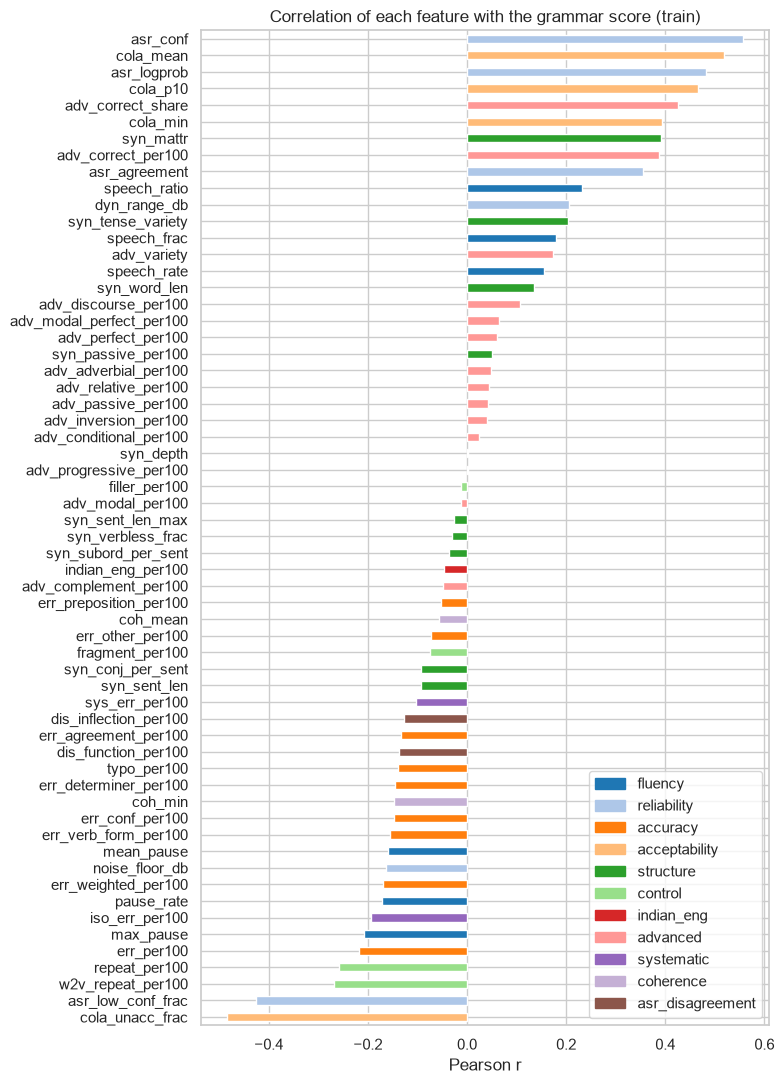

In [17]:
lab = df.set_index("key").label
trk = [k for k in F.index if k.startswith("train/")]
corr = F.loc[trk].apply(lambda c: pearsonr(c.fillna(c.median()), lab[trk])[0]).sort_values()
group_of = {c: g for g, cs in GROUPS.items() for c in cs}
pal = dict(zip(GROUPS, sns.color_palette("tab20", len(GROUPS))))
fig, ax = plt.subplots(figsize=(8, 11))
corr.plot.barh(ax=ax, color=[pal[group_of[c]] for c in corr.index])
ax.legend([plt.Rectangle((0, 0), 1, 1, color=pal[g]) for g in GROUPS], GROUPS, loc="lower right")
ax.set(title="Correlation of each feature with the grammar score (train)", xlabel="Pearson r")
plt.tight_layout(); plt.show()

## 8. Model

* **Training set:** all labelled clips except the noise-only ones.
* **Validation: grouped CV.** Voice embeddings show that neighbouring file IDs come from the same speaker or
  recording session (a clip's most similar voice is within ±3 IDs about half the time, against ~1 % by chance).
  With random folds the same voice appears in training and validation, and the audio model partly recognises voices
  instead of judging grammar (WavLM r 0.808 → 0.777 when this is prevented). A real engine always meets new
  speakers, so folds keep blocks of 25 consecutive file IDs together (`StratifiedGroupKFold`, 5 folds × 3 repeats).
  Imputation, scaling and PCA are fit inside each fold.
* **Final engine:** fine-tuned DeBERTa on the clean transcript, fine-tuned DeBERTa on the raw transcript, and a
  ridge model on WavLM audio embeddings, blended with non-negative weights and linearly calibrated. Blend weights and
  calibration are evaluated with nested CV, so the reported scores are honest.
* **Hand-built features** (Section 7) are kept for interpretation and the ablation; once text and audio models are
  in, they add < 0.001 Pearson, so they are not part of the scoring path.

In [18]:
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.optimize import nnls
from sklearn.svm import SVR
from lightgbm import LGBMRegressor

train_keys = [k for k in F.index if k.startswith("train/")]
X, E, y = F.loc[train_keys], EMB.loc[train_keys], lab[train_keys].values
strata = np.clip(np.round(y * 2) / 2, 2.0, 5.0).astype(str)
file_id = np.array([int(re.findall(r"\d+", k)[0]) for k in train_keys])
groups = file_id // 25                     # neighbouring IDs share a speaker/session: keep each block in one fold
folds = [s for r in range(3) for s in StratifiedGroupKFold(5, shuffle=True, random_state=r).split(X, strata, groups)]

ridge = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30)))
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=15, max_depth=4, min_child_samples=20,
                     subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0, random_state=SEED,
                     verbose=-1)
emb_ridge = make_pipeline(StandardScaler(), PCA(n_components=min(32, len(y) // 3), random_state=SEED),
                          RidgeCV(alphas=np.logspace(-1, 4, 30)))

rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
score = lambda p: dict(pearson=pearsonr(p, y)[0], rmse=rmse(p, y))

def oof(model, Xm):
    pred, cnt = np.zeros(len(y)), np.zeros(len(y))
    for tr_i, va_i in folds:
        pred[va_i] += clone(model).fit(Xm.iloc[tr_i], y[tr_i]).predict(Xm.iloc[va_i]); cnt[va_i] += 1
    return pred / cnt

### 8.1 Ablation: what each feature group adds

In [19]:
rows, cols = [], []
for i, g in enumerate(["fluency", "reliability", "accuracy", "acceptability", "structure", "advanced", "systematic",
                       "coherence", "control", "indian_eng", "asr_disagreement"]):
    cols += GROUPS[g]
    for name, m in [("ridge", ridge), ("lgbm", lgbm)]:
        rows.append(dict(step=("+ " if i else "") + g, model=name, **score(oof(m, X[cols]))))
rows.append(dict(step="embeddings only", model="ridge", **score(oof(emb_ridge, E))))
ablation = pd.DataFrame(rows)
display(ablation.pivot_table(index="step", columns="model", values=["pearson", "rmse"], sort=False).round(3))

pearson          rmse       
model                ridge   lgbm  ridge   lgbm
step                                           
fluency              0.254  0.170  0.982  1.035
+ reliability        0.626  0.611  0.791  0.805
+ accuracy           0.627  0.633  0.790  0.786
+ acceptability      0.663  0.669  0.759  0.755
+ structure          0.706  0.713  0.719  0.711
+ advanced           0.702  0.716  0.723  0.708
+ systematic         0.701  0.715  0.724  0.709
+ coherence          0.700  0.718  0.725  0.705
+ control            0.706  0.723  0.719  0.701
+ indian_eng         0.704  0.723  0.721  0.701
+ asr_disagreement   0.704  0.724  0.721  0.699
embeddings only      0.657    NaN  0.765    NaN

### 8.2 Fine-tuned DeBERTa on the transcripts

Hand-built features plateaued at CV r ≈ 0.78 (Section 8.1 and `development/EXPERIMENTS.md`). A transformer fine-tuned to
predict the score reads the transcript directly and learns grammar patterns no rule lists.
`microsoft/deberta-v3-base` with a 1-unit regression head, standardised target, MSE loss, 4 epochs, lr 2e-5,
batch 8, linear warm-up/decay, trained once per CV fold (the first 5 folds of the same repeated split), so its
out-of-fold predictions line up with the other models. Test predictions are the average of the 5 fold models.
Two views are trained: the **clean** transcript and the **raw** transcript with fillers and repetitions kept, each once per grouped fold (the first 5 folds), so out-of-fold predictions line up with the other models. Trained only on competition data. About 1 h each on an Apple M4 GPU; results are cached.

In [20]:
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

DEBERTA = {"deberta_clean": ("clean", 42), "deberta_raw": ("raw", 7)}     # tag -> (transcript view, seed)
CACHE_TAG = {"deberta_clean": "deberta-v3-base-g", "deberta_raw": "deberta-v3-base-g-raw"}
TEXT_VIEWS = {"clean": views.clean, "raw": asr.text}
test_keys = [k for k in F.index if k.startswith("test/")]

def finetune(view, seed, model_name="microsoft/deberta-v3-base", epochs=4, batch=8, lr=2e-5, max_len=384):
    tok = AutoTokenizer.from_pretrained(model_name)
    text = TEXT_VIEWS[view]
    enc = lambda keys: {k: v.to(TORCH_DEVICE) for k, v in tok([text[k] for k in keys], truncation=True,
                        max_length=max_len, padding=True, return_tensors="pt").items()}
    mu, sd = y.mean(), y.std()
    def predict_keys(model, keys):
        model.eval(); out = []
        with torch.no_grad():
            for i in range(0, len(keys), 16):
                out.append(model(**enc(keys[i:i + 16])).logits.squeeze(-1).float().cpu().numpy())
        return np.concatenate(out) * sd + mu
    oof_pred, test_pred = np.zeros(len(y)), []
    for fi, (tr, va) in enumerate(folds[:5]):
        torch.manual_seed(seed + fi); np.random.seed(seed + fi)
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1,
                                                                   dtype=torch.float32).to(TORCH_DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        steps = epochs * int(np.ceil(len(tr) / batch))
        sched = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
        target = torch.tensor(((y[tr] - mu) / sd).astype(np.float32))
        for _ in range(epochs):
            model.train()
            order = np.random.permutation(len(tr))
            for i in range(0, len(order), batch):
                idx_b = order[i:i + batch]
                logits = model(**enc([train_keys[tr[j]] for j in idx_b])).logits.squeeze(-1).float()
                loss = torch.nn.functional.mse_loss(logits, target[idx_b].to(TORCH_DEVICE))
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step(); opt.zero_grad()
        oof_pred[va] = predict_keys(model, [train_keys[i] for i in va])
        test_pred.append(predict_keys(model, test_keys))
        del model
    return (pd.Series(oof_pred, index=train_keys).to_frame("pred"),
            pd.Series(np.mean(test_pred, axis=0), index=test_keys).to_frame("pred"))

deberta_oof, deberta_test = {}, {}
for tag, (view, seed) in DEBERTA.items():
    po, pt = CACHE / "exp" / f"oof_{CACHE_TAG[tag]}.parquet", CACHE / "exp" / f"test_{CACHE_TAG[tag]}.parquet"
    if not (po.exists() and pt.exists()):
        o, t = finetune(view, seed); o.to_parquet(po); t.to_parquet(pt)
    deberta_oof[tag], deberta_test[tag] = pd.read_parquet(po).pred, pd.read_parquet(pt).pred
    print(tag, {k: round(v, 4) for k, v in score(deberta_oof[tag].loc[train_keys].values).items()})

deberta_clean {'pearson': np.float64(0.8104), 'rmse': 0.6045}
deberta_raw {'pearson': np.float64(0.8049), 'rmse': 0.6112}


### 8.3 Audio model: WavLM embeddings

Transcripts lose rhythm, hesitation and pronunciation, which raters hear. Recent spoken-assessment systems fuse a
speech model with a text model (e.g. Speak & Improve 2025: wav2vec 2.0 0.394 RMSE, text 0.389, fused 0.375).
Here, WavLM-base-plus hidden states (layers 6, 9, 12) are mean-pooled over the speech span and fed to PCA(64) +
ridge. Frozen embeddings are used: fine-tuning WavLM did not fit in 16 GB of memory.

In [21]:
from transformers import AutoFeatureExtractor, WavLMModel
WAVLM, WAV_LAYERS = "microsoft/wavlm-base-plus", [3, 6, 9, 12]
wav_path = CACHE / "exp" / "wavlm.parquet"
W = pd.read_parquet(wav_path) if wav_path.exists() else pd.DataFrame()
todo = [k for k in views.index if k not in W.index]
if todo:
    fe = AutoFeatureExtractor.from_pretrained(WAVLM)
    wm = WavLMModel.from_pretrained(WAVLM, dtype=torch.float32).to(TORCH_DEVICE).eval()
    meta_v, rows = clips.set_index("key"), {}
    for k in tqdm(todo, desc="WavLM"):
        a, _ = librosa.load(meta_v.path[k], sr=SR)
        s, e = int(meta_v.speech_start[k] * SR), int(meta_v.speech_end[k] * SR)
        a = a[s:e] if e - s > SR else a
        with torch.no_grad():
            hs = wm(**{n: v.to(TORCH_DEVICE) for n, v in fe(a, sampling_rate=SR, return_tensors="pt").items()},
                    output_hidden_states=True).hidden_states
        rows[k] = np.concatenate([hs[l][0].mean(0).cpu().numpy() for l in WAV_LAYERS])
    new = pd.DataFrame.from_dict(rows, orient="index")
    new.columns = [f"L{l}_{j}" for l in WAV_LAYERS for j in range(768)]
    W = pd.concat([W, new]); W.to_parquet(wav_path)

WCOLS = [c for c in W if c.startswith(("L6_", "L9_", "L12_"))]
wav_ridge = make_pipeline(StandardScaler(), PCA(64, random_state=SEED), RidgeCV(alphas=np.logspace(-1, 4, 30)))
wav_oof = pd.Series(oof(wav_ridge, W.loc[train_keys, WCOLS]), index=train_keys)
wav_final = clone(wav_ridge).fit(W.loc[train_keys, WCOLS], y)
print("WavLM audio model", {k: round(v, 4) for k, v in score(wav_oof.values).items()},
      f"| correlation with clean-transcript DeBERTa {np.corrcoef(wav_oof, deberta_oof['deberta_clean'].loc[train_keys])[0, 1]:.2f}")

WavLM audio model {'pearson': np.float64(0.7774), 'rmse': 0.6377} | correlation with clean-transcript DeBERTa 0.79


### 8.4 Blend and calibration

`nested(...)` learns blend weights and calibration on the outer-training part of each grouped split and predicts the
held-out part, so the `final` row is an honest estimate.

In [22]:
OOFS = {t: deberta_oof[t].loc[train_keys].values for t in DEBERTA}
OOFS["wavlm"] = wav_oof.values
names = list(DEBERTA) + ["wavlm"]

def nested(cols):
    Pm = np.column_stack([OOFS[c] for c in cols])
    out, cnt = np.zeros(len(y)), np.zeros(len(y))
    for tr_i, va_i in folds:
        wi, _ = nnls(Pm[tr_i], y[tr_i]); wi /= wi.sum()
        ci = LinearRegression().fit((Pm[tr_i] @ wi)[:, None], y[tr_i])
        out[va_i] += np.clip(ci.predict((Pm[va_i] @ wi)[:, None]), 0, 5); cnt[va_i] += 1
    return out / cnt

P = pd.DataFrame(OOFS, index=train_keys)
w, _ = nnls(P[names].values, y); w = w / w.sum()                 # final weights, from all OOF predictions
P["blend"] = P[names].values @ w
calibrator = LinearRegression().fit(P.blend.values[:, None], y)
P["final"] = nested(names)

comparison = pd.DataFrame({"text only (2 × DeBERTa)": score(nested(list(DEBERTA))),
                           "audio only (WavLM)": score(nested(["wavlm"])),
                           "text + audio (engine)": score(P.final.values)}).T
print("blend weights:", {n: round(float(v), 2) for n, v in zip(names, w)})
display(comparison.round(4))

blend weights: {'deberta_clean': 0.39, 'deberta_raw': 0.2, 'wavlm': 0.41}


,pearson,rmse
text only (2 × DeBERTa),0.8115,0.5925
audio only (WavLM),0.7743,0.6416
text + audio (engine),0.8369,0.5549


### 8.5 Training RMSE (required)

The WavLM model is refit on all training clips and scored on the same clips. DeBERTa has one model per fold, not a
single full-data model, so its part of the training prediction uses its out-of-fold predictions; this makes the
training RMSE slightly conservative. The cross-validated row is the honest estimate.

In [23]:
def member_preds(keys, deberta_from_oof=False):
    cols = {t: (deberta_oof if deberta_from_oof else deberta_test)[t].loc[keys].values for t in DEBERTA}
    cols["wavlm"] = wav_final.predict(W.loc[keys, WCOLS])
    return np.column_stack([cols[n] for n in names])

def predict(keys, deberta_from_oof=False):
    # the engine: calibrated blend of the three members for a list of clip keys
    return np.clip(calibrator.predict((member_preds(keys, deberta_from_oof) @ w)[:, None]), 0, 5)

train_pred = predict(train_keys, deberta_from_oof=True)
summary = pd.DataFrame({"train (in-sample)": score(train_pred), "cross-validated (grouped, nested)": score(P.final)}).T
display(summary.round(4))
print(f"TRAINING RMSE: {rmse(train_pred, y):.4f}")

,pearson,rmse
train (in-sample),0.8621,0.5139
"cross-validated (grouped, nested)",0.8369,0.5549


TRAINING RMSE: 0.5139


## 9. Evaluation and interpretation

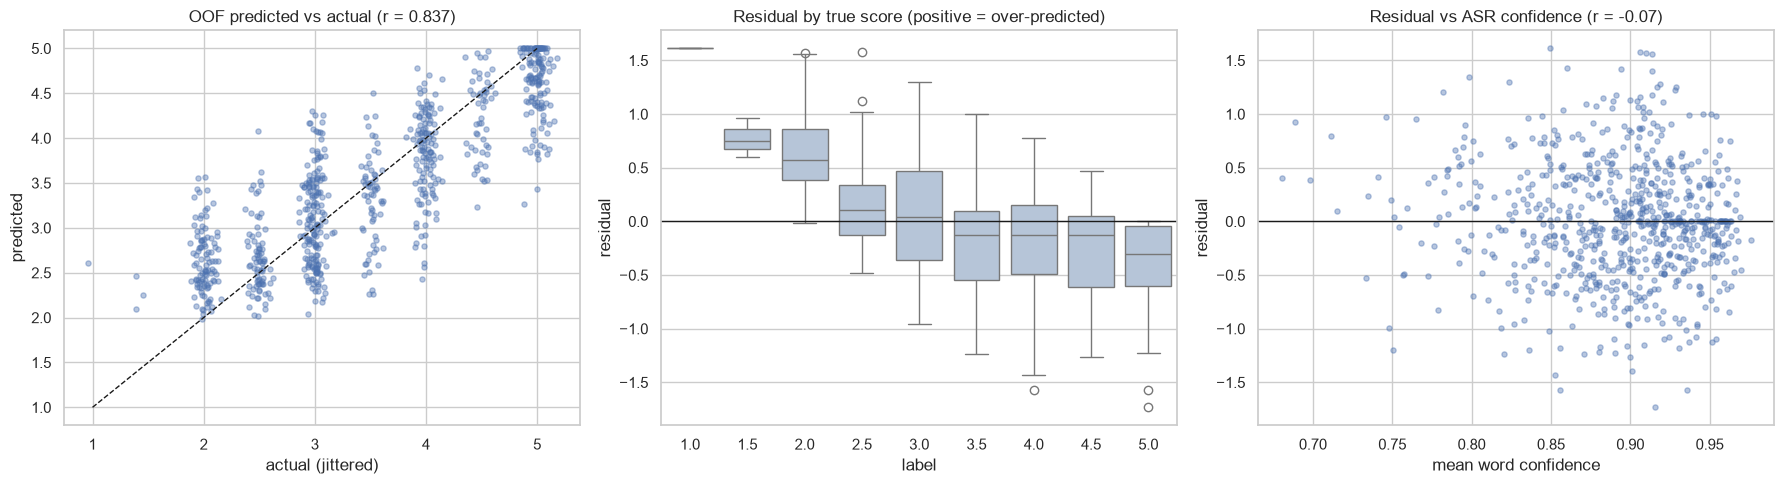

,n,bias,rmse
label,,,
1.0,1,1.612,1.612
1.5,3,0.771,0.786
2.0,102,0.631,0.727
2.5,79,0.167,0.440
3.0,174,0.090,0.526
3.5,64,-0.195,0.540
4.0,124,-0.186,0.517
4.5,52,-0.254,0.510
5.0,133,-0.377,0.536


In [24]:
p = P.final.values
res = pd.DataFrame({"key": train_keys, "label": y, "pred": p, "residual": p - y})
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].scatter(y + rng.normal(0, 0.06, len(y)), p, alpha=0.4, s=14); ax[0].plot([1, 5], [1, 5], "k--", lw=1)
ax[0].set(title=f"OOF predicted vs actual (r = {pearsonr(p, y)[0]:.3f})", xlabel="actual (jittered)", ylabel="predicted")
sns.boxplot(data=res, x="label", y="residual", ax=ax[1], color="lightsteelblue"); ax[1].axhline(0, color="k", lw=1)
ax[1].set(title="Residual by true score (positive = over-predicted)")
ax[2].scatter(X.asr_conf, res.residual, alpha=0.4, s=14); ax[2].axhline(0, color="k", lw=1)
ax[2].set(title=f"Residual vs ASR confidence (r = {pearsonr(X.asr_conf.fillna(X.asr_conf.median()), res.residual)[0]:.2f})",
          xlabel="mean word confidence", ylabel="residual")
plt.tight_layout(); plt.show()
display(res.groupby("label").residual.agg(n="size", bias="mean", rmse=lambda r: np.sqrt((r ** 2).mean())).round(3))

### 9.1 Accent robustness

No accent labels exist, so two proxies are used: Whisper's mean word confidence (accented or unclear speech gets
lower confidence) and four voice clusters from early WavLM layers, which mostly encode voice and accent. For each
group: error, and *bias* (mean predicted − true). A fair engine has small bias in every group.

In [25]:
from sklearn.cluster import KMeans
voice = W.loc[train_keys, [c for c in W if c.startswith("L3_")]]
voice_cluster = KMeans(4, n_init=10, random_state=SEED).fit_predict(
    PCA(20, random_state=SEED).fit_transform(StandardScaler().fit_transform(voice)))
text_only = nested(list(DEBERTA))
proxies = {"ASR confidence": pd.qcut(X.asr_conf.values, 3, labels=["low (accented/unclear)", "mid", "high (clear)"]),
           "voice cluster": pd.Series(voice_cluster).map(lambda c: f"cluster {c}").values}
for pname, g in proxies.items():
    rows = []
    for lvl in pd.unique(g):
        m = np.asarray(g == lvl)
        rows.append({"group": lvl, "n": int(m.sum()), "mean true score": y[m].mean(),
                     "RMSE text only": rmse(text_only[m], y[m]), "RMSE engine": rmse(P.final.values[m], y[m]),
                     "bias engine": (P.final.values[m] - y[m]).mean()})
    print(f"by {pname}"); display(pd.DataFrame(rows).set_index("group").sort_index().round(3))

by ASR confidence


,n,mean true score,RMSE text only,RMSE engine,bias engine
group,,,,,
high (clear),244,4.258,0.529,0.472,-0.057
low (accented/unclear),244,2.797,0.582,0.563,0.027
mid,244,3.387,0.659,0.620,0.023


by voice cluster


,n,mean true score,RMSE text only,RMSE engine,bias engine
group,,,,,
cluster 0,177,3.268,0.654,0.605,-0.103
cluster 1,141,3.227,0.580,0.558,0.012
cluster 2,310,3.848,0.538,0.507,0.019
cluster 3,104,3.091,0.649,0.596,0.087


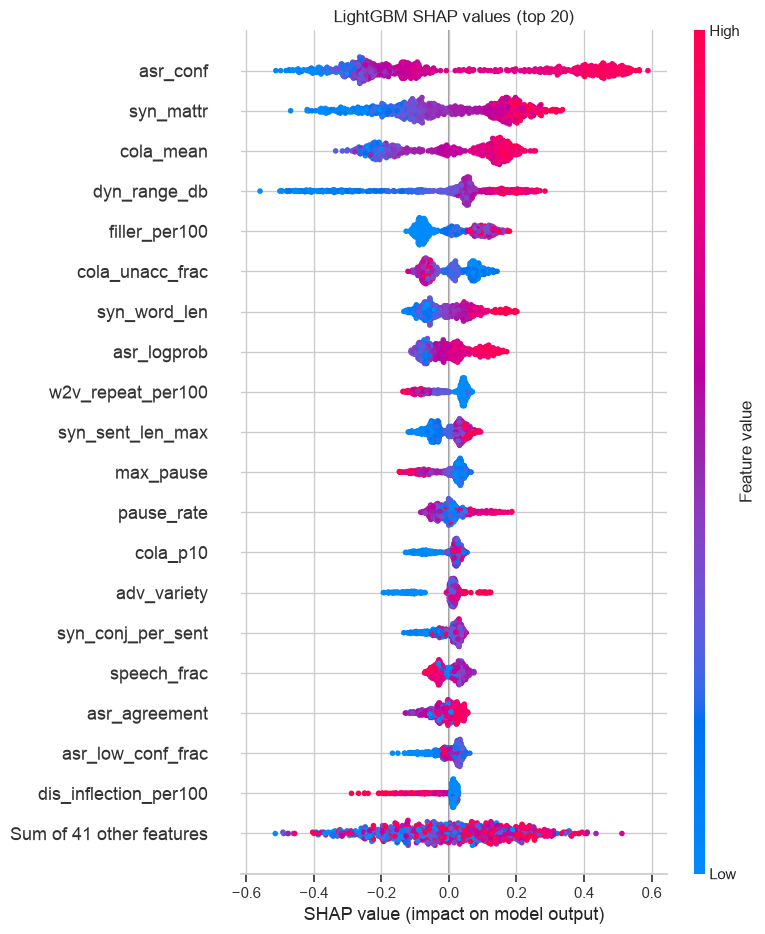

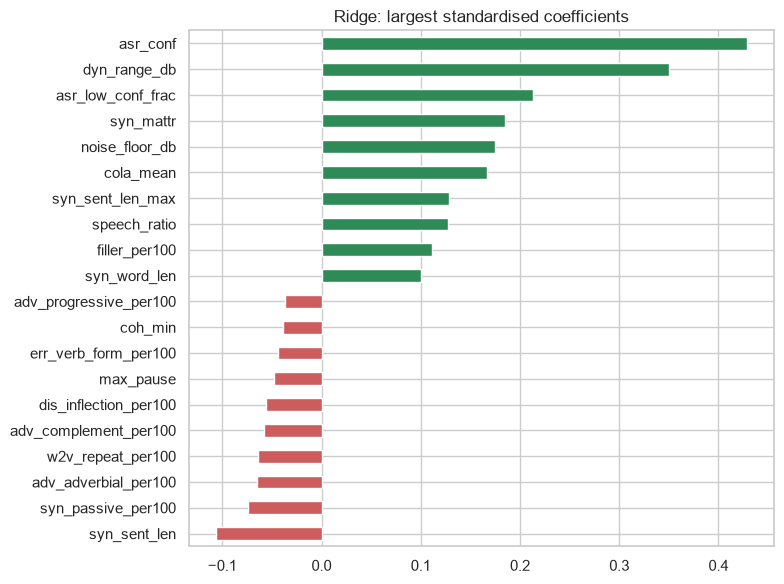

In [26]:
import shap
interp = {"ridge": clone(ridge).fit(X, y), "lgbm": clone(lgbm).fit(X, y)}   # feature models, for interpretation only
sv = shap.TreeExplainer(interp["lgbm"])(X)
shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title("LightGBM SHAP values (top 20)"); plt.tight_layout(); plt.show()

coef = pd.Series(interp["ridge"][-1].coef_, index=X.columns).sort_values()
coef = pd.concat([coef.head(10), coef.tail(10)])
coef.plot.barh(figsize=(8, 6), color=["indianred" if v < 0 else "seagreen" for v in coef])
plt.title("Ridge: largest standardised coefficients"); plt.tight_layout(); plt.show()

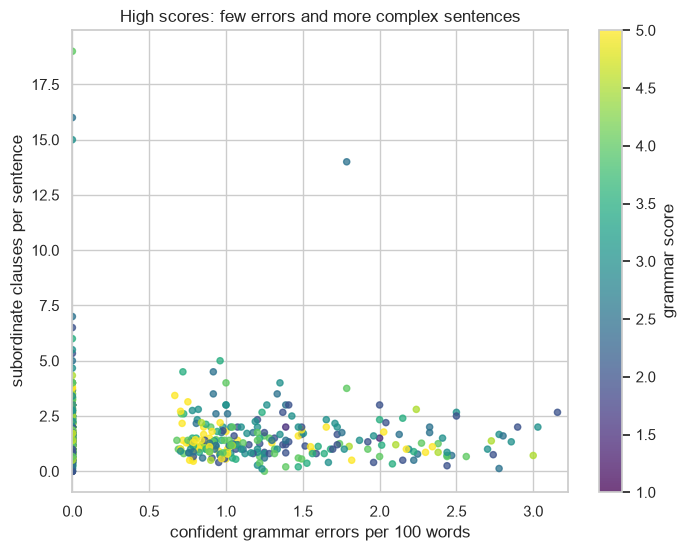


train/audio_733.wav  label 5.0  predicted 3.27  CoLA mean 0.82  errors/100 0.8  ASR conf 0.92
   My favorite place to visit is the National Park. I like to visit a National Park, especially Kruger National Park, because I'm a person that is very close to nature. I like animals. I like to be in a quiet place where nature evolves, because the nature, it makes, it gives me strength. It makes me ha

train/audio_357.wav  label 5.0  predicted 3.43  CoLA mean 0.82  errors/100 0.0  ASR conf 0.94
   There were slides and monkey bars and swing sets. They were all colorful. It was a, it was like a big jungle gym. You hear laughter, kids running, chasing each other, laughing. Some kids crying. A lot of kids smiling. There was a lot of, it was a big, There's a horde of kids playing on the monkey ba

train/audio_108.wav  label 1.0  predicted 2.61  CoLA mean 0.39  errors/100 0.0  ASR conf 0.85
   As a young child, one of the most exciting place to be was the playground. It was a place where the rule

In [27]:
# the rubric's two axes: accuracy (errors) and complexity (subordination)
fig, ax = plt.subplots(figsize=(8, 6))
s = ax.scatter(X.err_conf_per100, X.syn_subord_per_sent, c=y, cmap="viridis", alpha=0.75, s=20)
plt.colorbar(s, label="grammar score")
ax.set(xlabel="confident grammar errors per 100 words", ylabel="subordinate clauses per sentence",
       title="High scores: few errors and more complex sentences", xlim=(0, np.nanpercentile(X.err_conf_per100, 99)))
plt.show()

for _, r in pd.concat([res.nsmallest(2, "residual"), res.nlargest(2, "residual")]).iterrows():
    print(f"\n{r.key}  label {r.label}  predicted {r.pred:.2f}  CoLA mean {X.cola_mean[r.key]:.2f}  "
          f"errors/100 {X.err_conf_per100[r.key]:.1f}  ASR conf {X.asr_conf[r.key]:.2f}")
    print("  ", views.clean[r.key][:300])

## 10. Test predictions and submission

count    216.000
mean       3.276
std        0.819
min        1.934
25%        2.606
50%        3.159
75%        3.822
max        5.000
Name: label, dtype: float64


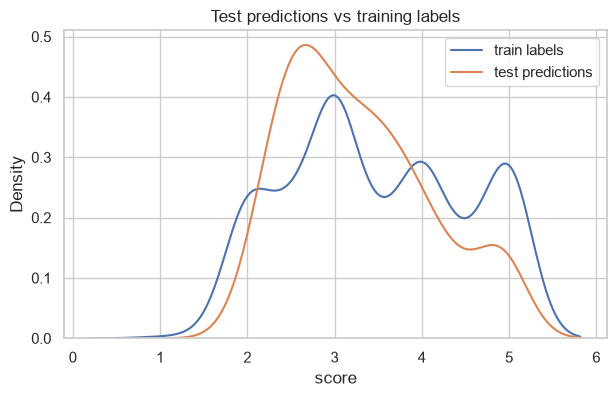

In [28]:
sub = test[["filename"]].copy()
keys = ("test/" + sub.filename).tolist()
noise = df.set_index("key").noise_only.reindex(keys).values
pred = np.zeros(len(keys))
ok = [k for k, nz in zip(keys, noise) if not nz]
pred[~noise] = predict(ok)
sub["label"] = pred.round(4)
sub.to_csv("submission.csv", index=False)
print(sub.label.describe().round(3))

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(y, ax=ax, label="train labels"); sns.kdeplot(sub.label, ax=ax, label="test predictions")
ax.set(title="Test predictions vs training labels", xlabel="score"); ax.legend(); plt.show()

## 11. Report

**Problem.** Predict a 0–5 grammar score from 45–60 s of spoken English, mostly Indian-accented. The rubric scores
sentence structure, accuracy, complex grammar and self-correction.

**Preprocessing.**
* 37 training clips scored 0 are steady white noise (dynamic range ≈ 3 dB vs ≈ 40 dB for speech). A three-statistic
  rule flags exactly these and no test clip; they are excluded from training and predicted 0 if ever seen.
* Silero VAD finds speech; transcription runs on the speech span only, which avoids hallucinated text in silence.
* Whisper medium gives the main transcript with per-word confidence; wav2vec2 CTC (no language model) gives a
  literal second transcript. Each transcript has a raw view (fillers, repeats, restarts kept) and a clean view.
* Test clips are shorter than training clips (45 vs 60 s), so all hand-built features are rates.

**Engine.** Fine-tuned DeBERTa-v3-base on the clean transcript (weight 0.39) and on the raw transcript (0.20), plus
ridge on mean-pooled WavLM audio embeddings (0.41), combined with non-negative weights and a linear calibration.

**Results** (speaker-grouped, nested cross-validation on 732 clips):

| Model | Pearson | RMSE |
|---|---|---|
| Hand-built features only (LightGBM) | 0.73 | 0.69 |
| Text only (2 × DeBERTa) | 0.812 | 0.593 |
| Audio only (WavLM) | 0.774 | 0.642 |
| **Engine: text + audio** | **0.837** | **0.555** |
| Training RMSE (required) | | **0.514** |

Public leaderboard (60 % of the test set): 0.463 with hand-built features only, 0.362–0.364 with DeBERTa.

**How the evaluation was made trustworthy.**
* *Label-shuffle test:* trained on shuffled scores, every model collapses to r ≈ 0, so nothing leaks the target.
* *Nested CV:* blend weights and calibration are learned inside each outer fold.
* *Speaker grouping:* voice embeddings showed neighbouring file IDs share a speaker or session. Random folds let the
  audio model recognise voices (WavLM 0.808 → 0.777 once prevented); all reported numbers use grouped folds.
* *Adversarial validation* (train vs test AUC 0.73) showed recording conditions differ between sets; dropping the
  recording features to "fix" this made the leaderboard worse, so they carry real signal.

**Accent robustness (Section 9.1).** Using Whisper confidence and voice clusters as accent proxies, adding audio
lowered error in every group and mean bias stays within ±0.10 points. Accented/unclear speakers have lower true
scores on average (2.80 vs 4.26 for the clearest third), but the engine does not score them below the raters.

**What did not help** (details in `development/EXPERIMENTS.md`): advanced-grammar counts (inversion, conditionals, modals),
answer-length features, coherence, isotonic calibration, stacking, a local LLM judge (Qwen2.5-7B, r ≈ 0.5–0.6 alone,
redundant next to DeBERTa), DeBERTa-large and fine-tuned WavLM (both exceed 16 GB of memory).

**Limitations.** Accent proxies are not true accent labels. Only 4 clips score below 2.0, so the low end is poorly
estimated. Audio cues reflect clarity and fluency as well as grammar; raters' scores do too, but a pure grammar score
would need labels that separate them. Pretrained models are used as-is or fine-tuned only on competition data.